## Module 2 | Day 4: Optimization foundations

### 1. Loss (Cost) Functions

#### 1.1 Introduction to Loss Functions

A loss function measures how far a model's predictions are from the actual values. The goal of training is to minimize this loss.

Loss Functions Comparison:
True values: [1 2 3 4 5]
Predictions: [1.2 1.8 3.5 3.8 5.5]

MSE: 0.1240
MAE: 0.3200
Huber Loss: 0.0620


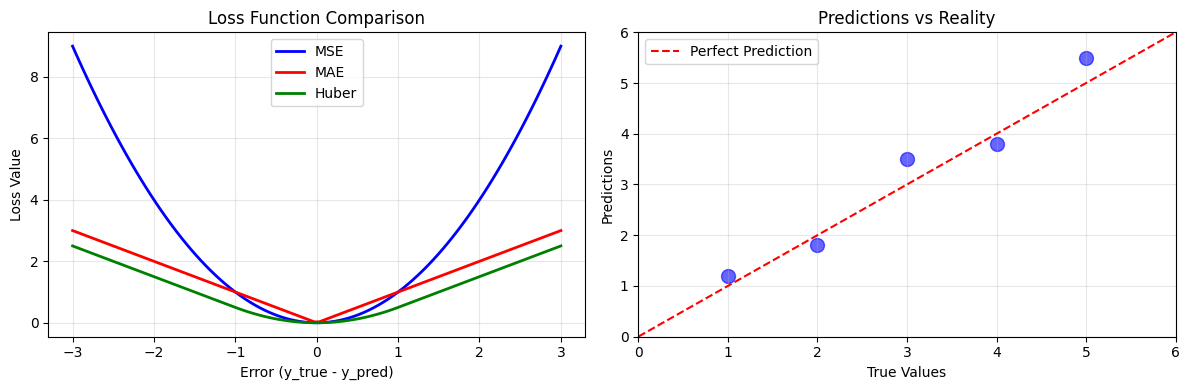


💡 ML Connection:
MSE is sensitive to outliers (penalizes large errors heavily)
MAE is more robust to outliers
Huber combines advantages of both


In [1]:

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Common loss functions
def mse(y_true, y_pred):
    """Mean Squared Error"""
    return np.mean((y_true - y_pred) ** 2)

def mae(y_true, y_pred):
    """Mean Absolute Error"""
    return np.mean(np.abs(y_true - y_pred))

def huber_loss(y_true, y_pred, delta=1.0):
    """Huber Loss - combines MSE and MAE"""
    diff = y_true - y_pred
    is_small = np.abs(diff) <= delta
    squared_loss = 0.5 * diff ** 2
    linear_loss = delta * (np.abs(diff) - 0.5 * delta)
    return np.where(is_small, squared_loss, linear_loss)

# Generate data
y_true = np.array([1, 2, 3, 4, 5])
y_pred = np.array([1.2, 1.8, 3.5, 3.8, 5.5])

print("Loss Functions Comparison:")
print(f"True values: {y_true}")
print(f"Predictions: {y_pred}")
print(f"\nMSE: {mse(y_true, y_pred):.4f}")
print(f"MAE: {mae(y_true, y_pred):.4f}")
print(f"Huber Loss: {np.mean(huber_loss(y_true, y_pred)):.4f}")

# Visualize different loss functions
plt.figure(figsize=(12, 4))

# Plot 1: Loss values for different predictions
errors = np.linspace(-3, 3, 100)
mse_values = errors ** 2
mae_values = np.abs(errors)
huber_values = huber_loss(0, errors, delta=1.0)

plt.subplot(1, 2, 1)
plt.plot(errors, mse_values, 'b-', label='MSE', linewidth=2)
plt.plot(errors, mae_values, 'r-', label='MAE', linewidth=2)
plt.plot(errors, huber_values, 'g-', label='Huber', linewidth=2)
plt.xlabel('Error (y_true - y_pred)')
plt.ylabel('Loss Value')
plt.title('Loss Function Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Model predictions visualization
plt.subplot(1, 2, 2)
plt.scatter(y_true, y_pred, color='blue', s=100, alpha=0.6)
plt.plot([0, 6], [0, 6], 'r--', label='Perfect Prediction')
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('Predictions vs Reality')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 6)
plt.ylim(0, 6)

plt.tight_layout()
plt.show()

print("\n💡 ML Connection:")
print("MSE is sensitive to outliers (penalizes large errors heavily)")
print("MAE is more robust to outliers")
print("Huber combines advantages of both")

### 1.2 Classification Loss Functions

Cross-entropy loss is commonly used for classification problems.

Classification Loss Functions:
Binary Cross-Entropy: 0.1643
Categorical Cross-Entropy: 0.5108


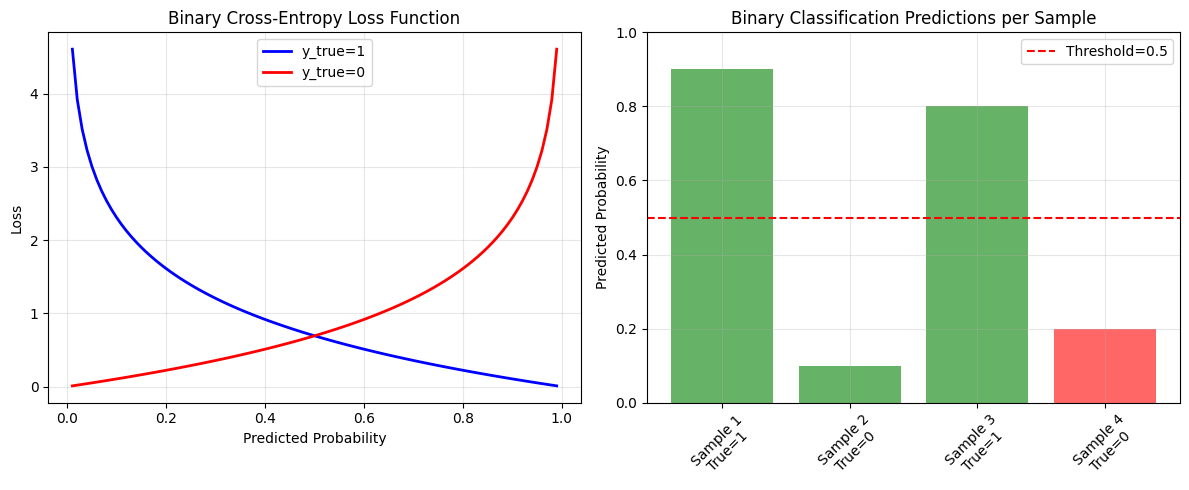


💡 ML Connection:
Cross-entropy is widely used in classification tasks
Encourages models to make confident predictions

📊 Cross-Entropy Comparison:
--------------------------------------------------
Good predictions (confident & correct): 0.0673
Bad predictions (confident & wrong):    2.7607
Uncertain predictions:                  0.6931


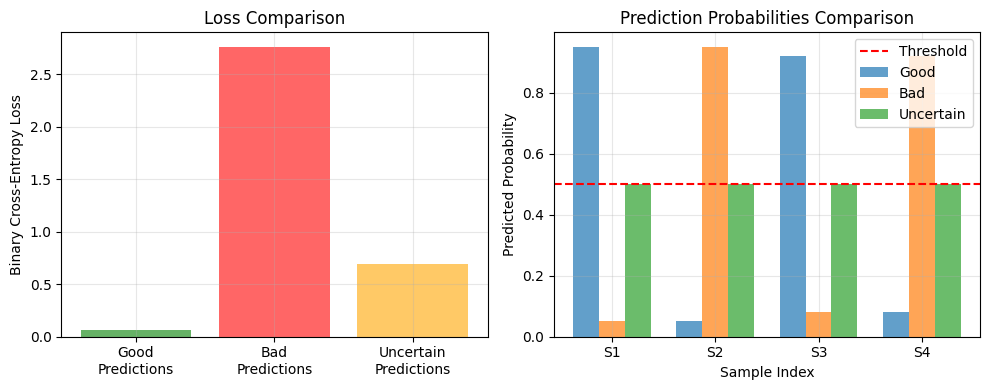

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Binary Cross-Entropy Loss
def binary_cross_entropy(y_true, y_pred):
    """Binary Cross-Entropy Loss"""
    epsilon = 1e-15  # Prevent log(0)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# Categorical Cross-Entropy (simplified)
def categorical_cross_entropy(y_true, y_pred):
    """Categorical Cross-Entropy Loss"""
    epsilon = 1e-15
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.sum(y_true * np.log(y_pred))

# Example: Binary classification
y_true_binary = np.array([1, 0, 1, 0])
y_pred_binary = np.array([0.9, 0.1, 0.8, 0.2])

# Example: Multi-class classification
y_true_multi = np.array([0, 0, 1, 0])  # One-hot encoding for class 2
y_pred_multi = np.array([0.1, 0.2, 0.6, 0.1])

print("Classification Loss Functions:")
print(f"Binary Cross-Entropy: {binary_cross_entropy(y_true_binary, y_pred_binary):.4f}")
print(f"Categorical Cross-Entropy: {categorical_cross_entropy(y_true_multi, y_pred_multi):.4f}")

# Visualize binary cross-entropy
p = np.linspace(0.01, 0.99, 100)
loss_when_true = -np.log(p)
loss_when_false = -np.log(1 - p)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(p, loss_when_true, 'b-', label='y_true=1', linewidth=2)
plt.plot(p, loss_when_false, 'r-', label='y_true=0', linewidth=2)
plt.xlabel('Predicted Probability')
plt.ylabel('Loss')
plt.title('Binary Cross-Entropy Loss Function')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# Plot each prediction separately with correct labels
sample_indices = range(len(y_pred_binary))
colors = ['green' if abs(y_pred_binary[i] - y_true_binary[i]) < 0.2 else 'red' 
          for i in range(len(y_pred_binary))]
labels = [f'Sample {i+1}\nTrue={y_true_binary[i]}' for i in range(len(y_pred_binary))]

plt.bar(labels, y_pred_binary, color=colors, alpha=0.6)
plt.axhline(y=0.5, color='red', linestyle='--', label='Threshold=0.5')
plt.title('Binary Classification Predictions per Sample')
plt.ylabel('Predicted Probability')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 ML Connection:")
print("Cross-entropy is widely used in classification tasks")
print("Encourages models to make confident predictions")

# Additional demonstration: Compare different prediction qualities
print("\n📊 Cross-Entropy Comparison:")
print("-" * 50)

# Good predictions
good_preds = np.array([0.95, 0.05, 0.92, 0.08])
good_loss = binary_cross_entropy(y_true_binary, good_preds)

# Bad predictions (confident but wrong)
bad_preds = np.array([0.05, 0.95, 0.08, 0.92])
bad_loss = binary_cross_entropy(y_true_binary, bad_preds)

# Uncertain predictions
uncertain_preds = np.array([0.5, 0.5, 0.5, 0.5])
uncertain_loss = binary_cross_entropy(y_true_binary, uncertain_preds)

print(f"Good predictions (confident & correct): {good_loss:.4f}")
print(f"Bad predictions (confident & wrong):    {bad_loss:.4f}")
print(f"Uncertain predictions:                  {uncertain_loss:.4f}")

# Visualize the comparison
plt.figure(figsize=(10, 4))

# Create bar chart showing different prediction scenarios
scenarios = ['Good\nPredictions', 'Bad\nPredictions', 'Uncertain\nPredictions']
losses = [good_loss, bad_loss, uncertain_loss]
colors = ['green', 'red', 'orange']

plt.subplot(1, 2, 1)
plt.bar(scenarios, losses, color=colors, alpha=0.6)
plt.ylabel('Binary Cross-Entropy Loss')
plt.title('Loss Comparison')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# Show actual predictions for each scenario
x = np.arange(len(y_true_binary))
width = 0.25

plt.bar(x - width, good_preds, width, label='Good', alpha=0.7)
plt.bar(x, bad_preds, width, label='Bad', alpha=0.7)
plt.bar(x + width, uncertain_preds, width, label='Uncertain', alpha=0.7)

plt.axhline(y=0.5, color='red', linestyle='--', label='Threshold')
plt.xlabel('Sample Index')
plt.ylabel('Predicted Probability')
plt.title('Prediction Probabilities Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(x, [f'S{i+1}' for i in range(len(y_true_binary))])

plt.tight_layout()
plt.show()

### 2. Gradient Descent Variant 

#### 2.1 Batch Gradient Descent

Batch GD uses the entire dataset to compute gradients. It's accurate but slow for large datasets.

Data shape check:
X shape: (100, 1)
y shape: (100,)
y[:5]: [6.33428778 9.40527849 8.48372443 5.60438199 4.71643995]
Iteration 0: Loss = 50.0083
Iteration 20: Loss = 0.9618
Iteration 40: Loss = 0.8825
Iteration 60: Loss = 0.8449
Iteration 80: Loss = 0.8259
Iteration 100: Loss = 0.8163
Iteration 120: Loss = 0.8115
Iteration 140: Loss = 0.8091
Iteration 160: Loss = 0.8078
Iteration 180: Loss = 0.8072

Final parameters:
Weight: 2.7987
Bias: 4.1827
Expected: Weight=3.0, Bias=4.0 (approx)


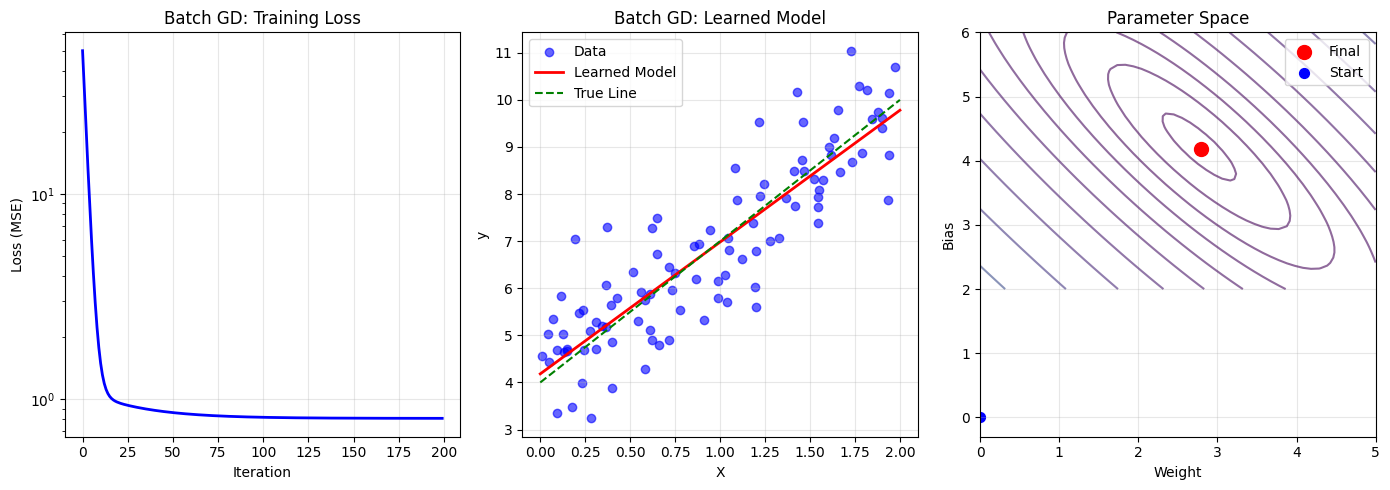


💡 ML Connection:
Batch GD is deterministic and stable but computationally expensive
Converged in 200 iterations
Final MSE: 0.806913

📊 Learning Rate Comparison:
Iteration 0: Loss = 50.0083
Iteration 20: Loss = 10.1169
Iteration 40: Loss = 2.7087
Iteration 60: Loss = 1.3150
Iteration 80: Loss = 1.0372
LR = 0.01: Final Loss = 0.970395, Weights = 3.3412, Bias = 3.4600
Iteration 0: Loss = 50.0083
Iteration 20: Loss = 0.9618
Iteration 40: Loss = 0.8825
Iteration 60: Loss = 0.8449
Iteration 80: Loss = 0.8259
LR = 0.05: Final Loss = 0.816656, Weights = 2.9286, Bias = 4.0356
Iteration 0: Loss = 50.0083
Iteration 20: Loss = 0.8816
Iteration 40: Loss = 0.8254
Iteration 60: Loss = 0.8113
Iteration 80: Loss = 0.8078
LR = 0.10: Final Loss = 0.806905, Weights = 2.7979, Bias = 4.1836
Iteration 0: Loss = 50.0083
Iteration 20: Loss = 608.6225
Iteration 40: Loss = 7555.3207
Iteration 60: Loss = 93895.5194
Iteration 80: Loss = 1167013.9306
LR = 0.50: Final Loss = 12787588.125915, Weights = -1983.9281, B

In [6]:
import numpy as np
import matplotlib.pyplot as plt

class BatchGradientDescent:
    def __init__(self, learning_rate=0.01, n_iterations=100):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        # Ensure y is a 1D array
        y = y.flatten()
        
        for iteration in range(self.n_iterations):
            # Forward pass - predictions
            y_pred = np.dot(X, self.weights) + self.bias
            
            # Compute loss (MSE)
            loss = np.mean((y - y_pred) ** 2)
            self.loss_history.append(loss)
            
            # Compute gradients (using entire dataset)
            # dw = (2/n) * X.T * (y_pred - y)
            dw = (2 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (2 / n_samples) * np.sum(y_pred - y)
            
            # Update parameters
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            
            if iteration % 20 == 0:
                print(f"Iteration {iteration}: Loss = {loss:.4f}")
        
        return self
    
    def predict(self, X):
        """Make predictions on new data"""
        return np.dot(X, self.weights) + self.bias

# Generate sample data
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)  # Keep as 2D for now
y = y.flatten()  # Convert to 1D

print("Data shape check:")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"y[:5]: {y[:5]}")

# Train using Batch GD
model = BatchGradientDescent(learning_rate=0.05, n_iterations=200)
model.fit(X, y)

print(f"\nFinal parameters:")
print(f"Weight: {model.weights[0]:.4f}")
print(f"Bias: {model.bias:.4f}")
print(f"Expected: Weight=3.0, Bias=4.0 (approx)")

# Visualize training
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.plot(model.loss_history, 'b-', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Loss (MSE)')
plt.title('Batch GD: Training Loss')
plt.grid(True, alpha=0.3)
plt.yscale('log')  # Log scale to see convergence better

plt.subplot(1, 3, 2)
plt.scatter(X, y, alpha=0.6, label='Data', color='blue')
X_line = np.linspace(0, 2, 100).reshape(-1, 1)
y_line = model.predict(X_line)
plt.plot(X_line, y_line, 'r-', linewidth=2, label='Learned Model')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Batch GD: Learned Model')
plt.legend()
plt.grid(True, alpha=0.3)

# Also show the true line
y_true_line = 4 + 3 * X_line
plt.plot(X_line, y_true_line, 'g--', linewidth=1.5, label='True Line')
plt.legend()

plt.subplot(1, 3, 3)
# Show gradient descent path (parameter space)
w_range = np.linspace(0, 5, 50)
b_range = np.linspace(2, 6, 50)
W, B = np.meshgrid(w_range, b_range)
Z = np.zeros_like(W)

for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        y_pred = W[i,j] * X + B[i,j]
        Z[i,j] = np.mean((y - y_pred.flatten()) ** 2)

plt.contour(W, B, Z, levels=np.logspace(-1, 2, 20), cmap='viridis', alpha=0.6)
plt.scatter([model.weights[0]], [model.bias], color='red', s=100, label='Final')
plt.scatter([0], [0], color='blue', s=50, label='Start')
plt.xlabel('Weight')
plt.ylabel('Bias')
plt.title('Parameter Space')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 ML Connection:")
print("Batch GD is deterministic and stable but computationally expensive")
print(f"Converged in {len(model.loss_history)} iterations")
print(f"Final MSE: {model.loss_history[-1]:.6f}")

# Compare with different learning rates
print("\n📊 Learning Rate Comparison:")
for lr in [0.01, 0.05, 0.1, 0.5]:
    model_temp = BatchGradientDescent(learning_rate=lr, n_iterations=100)
    model_temp.fit(X, y)
    final_loss = model_temp.loss_history[-1]
    print(f"LR = {lr:0.2f}: Final Loss = {final_loss:.6f}, Weights = {model_temp.weights[0]:.4f}, Bias = {model_temp.bias:.4f}")

### 2.2 Stochastic Gradient Descent (SGD)

SGD updates weights using one sample at a time, making it fast but noisy.

Data shape check:
X shape: (100, 1)
y shape: (100,)
y[:5]: [6.33428778 9.40527849 8.48372443 5.60438199 4.71643995]
Iteration 0: Loss = 50.0083
Iteration 20: Loss = 0.9618
Iteration 40: Loss = 0.8825
Iteration 60: Loss = 0.8449
Iteration 80: Loss = 0.8259
Iteration 100: Loss = 0.8163
Iteration 120: Loss = 0.8115
Iteration 140: Loss = 0.8091
Iteration 160: Loss = 0.8078
Iteration 180: Loss = 0.8072

Final parameters:
Weight: 2.7987
Bias: 4.1827
Expected: Weight=3.0, Bias=4.0 (approx)


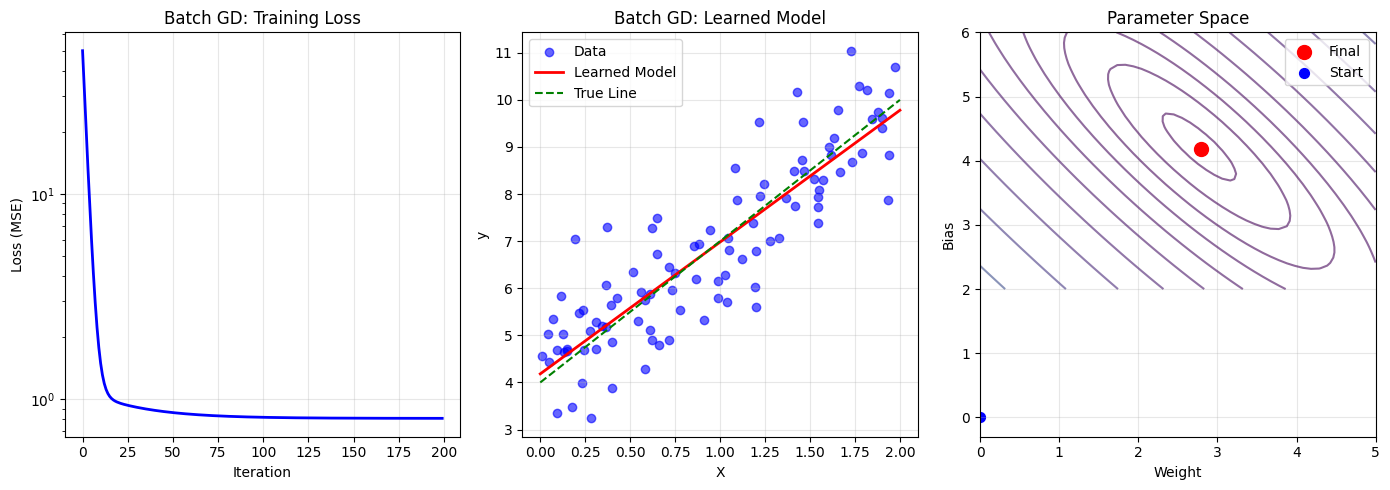


💡 ML Connection:
Batch GD is deterministic and stable but computationally expensive
Converged in 200 iterations
Final MSE: 0.806913

📊 Learning Rate Comparison:
Iteration 0: Loss = 50.0083
Iteration 20: Loss = 10.1169
Iteration 40: Loss = 2.7087
Iteration 60: Loss = 1.3150
Iteration 80: Loss = 1.0372
LR = 0.01: Final Loss = 0.970395, Weights = 3.3412, Bias = 3.4600
Iteration 0: Loss = 50.0083
Iteration 20: Loss = 0.9618
Iteration 40: Loss = 0.8825
Iteration 60: Loss = 0.8449
Iteration 80: Loss = 0.8259
LR = 0.05: Final Loss = 0.816656, Weights = 2.9286, Bias = 4.0356
Iteration 0: Loss = 50.0083
Iteration 20: Loss = 0.8816
Iteration 40: Loss = 0.8254
Iteration 60: Loss = 0.8113
Iteration 80: Loss = 0.8078
LR = 0.10: Final Loss = 0.806905, Weights = 2.7979, Bias = 4.1836
Iteration 0: Loss = 50.0083
Iteration 20: Loss = 608.6225
Iteration 40: Loss = 7555.3207
Iteration 60: Loss = 93895.5194
Iteration 80: Loss = 1167013.9306
LR = 0.50: Final Loss = 12787588.125915, Weights = -1983.9281, B

In [ ]:

class StochasticGradientDescent:
    def __init__(self, learning_rate=0.01, n_iterations=100):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        for iteration in range(self.n_iterations):
            # Shuffle data
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]
            
            epoch_loss = 0
            
            # Update using each sample individually
            for i in range(n_samples):
                xi = X_shuffled[i:i+1]
                yi = y_shuffled[i:i+1]
                
                # Forward pass
                y_pred = np.dot(xi, self.weights) + self.bias
                
                # Compute gradient (single sample)
                dw = -2 * xi.T * (yi - y_pred)
                db = -2 * (yi - y_pred)
                
                # Update parameters
                self.weights -= self.lr * dw.flatten()
                self.bias -= self.lr * db.flatten()
                
                epoch_loss += (yi - y_pred) ** 2
            
            avg_loss = epoch_loss / n_samples
            self.loss_history.append(avg_loss[0])
            
            if iteration % 20 == 0:
                print(f"Iteration {iteration}: Loss = {avg_loss[0]:.4f}")
        
        return self

# Train using SGD
model_sgd = StochasticGradientDescent(learning_rate=0.01, n_iterations=100)
model_sgd.fit(X, y)

print(f"\nFinal parameters (SGD):")
print(f"Weight: {model_sgd.weights[0]:.4f}")
print(f"Bias: {model_sgd.bias:.4f}")

# Compare SGD vs Batch GD
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(model.loss_history, 'b-', label='Batch GD', alpha=0.7, linewidth=2)
plt.plot(model_sgd.loss_history, 'r-', label='SGD', alpha=0.7, linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(X, y, alpha=0.6, label='Data')
X_line = np.linspace(0, 2, 100)
y_line_sgd = model_sgd.weights[0] * X_line + model_sgd.bias
plt.plot(X_line, y_line_sgd, 'r-', linewidth=2, label='SGD Model')
plt.xlabel('X')
plt.ylabel('y')
plt.title('SGD: Learned Model')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 ML Connection:")
print("SGD is faster but noisier than Batch GD")
print("Noise can help escape local minima!")

### 2.3 Mini-Batch Gradient Descent

Mini-Batch GD uses small batches of data, balancing speed and stability.

Iteration 0: Loss = 50.0083
Iteration 20: Loss = 10.1169
Iteration 40: Loss = 2.7087
Iteration 60: Loss = 1.3150
Iteration 80: Loss = 1.0372
Iteration 0: Loss = 33.1888
Iteration 20: Loss = 0.9599
Iteration 40: Loss = 0.8808
Iteration 60: Loss = 0.8441
Iteration 80: Loss = 0.8256
Iteration 0: Loss = 6.9793
Iteration 20: Loss = 0.8405
Iteration 40: Loss = 0.8287
Iteration 60: Loss = 0.8375
Iteration 80: Loss = 0.8377


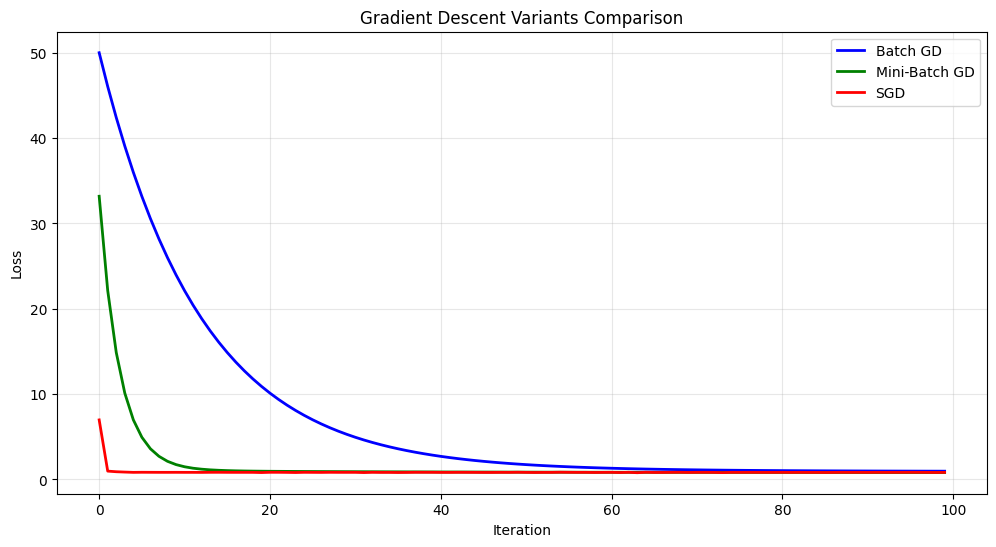


💡 ML Connection:
Mini-Batch GD is the most popular choice in deep learning
It balances speed (SGD) and stability (Batch GD)


In [9]:
class MiniBatchGradientDescent:
    def __init__(self, learning_rate=0.01, batch_size=20, n_iterations=100):
        self.lr = learning_rate
        self.batch_size = batch_size
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        for iteration in range(self.n_iterations):
            # Shuffle data
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]
            
            # Mini-batch training
            for i in range(0, n_samples, self.batch_size):
                X_batch = X_shuffled[i:i+self.batch_size]
                y_batch = y_shuffled[i:i+self.batch_size]
                
                # Forward pass
                y_pred = np.dot(X_batch, self.weights) + self.bias
                
                # Compute gradients (batch)
                dw = -2 * np.dot(X_batch.T, (y_batch - y_pred)) / len(X_batch)
                db = -2 * np.mean(y_batch - y_pred)
                
                # Update parameters
                self.weights -= self.lr * dw
                self.bias -= self.lr * db
            
            # Compute full loss
            y_pred_all = np.dot(X, self.weights) + self.bias
            loss = np.mean((y - y_pred_all) ** 2)
            self.loss_history.append(loss)
            
            if iteration % 20 == 0:
                print(f"Iteration {iteration}: Loss = {loss:.4f}")
        
        return self

# Compare all three variants
batch_sizes = ['Full (Batch)', 'Mini-Batch (20)', 'SGD (1)']
colors = ['blue', 'green', 'red']

plt.figure(figsize=(12, 6))

# Batch GD
model_batch = BatchGradientDescent(learning_rate=0.01, n_iterations=100)
model_batch.fit(X, y)

# Mini-Batch GD
model_mini = MiniBatchGradientDescent(learning_rate=0.01, batch_size=20, n_iterations=100)
model_mini.fit(X, y)

# SGD
model_sgd = StochasticGradientDescent(learning_rate=0.01, n_iterations=100)
model_sgd.fit(X, y)

plt.plot(model_batch.loss_history, 'b-', label='Batch GD', linewidth=2)
plt.plot(model_mini.loss_history, 'g-', label='Mini-Batch GD', linewidth=2)
plt.plot(model_sgd.loss_history, 'r-', label='SGD', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Gradient Descent Variants Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

print("\n💡 ML Connection:")
print("Mini-Batch GD is the most popular choice in deep learning")
print("It balances speed (SGD) and stability (Batch GD)")

### 3. learning rate Outcomes

####  3.1 Impact of Learning Rate

Learning rate determines step size in gradient descent. Too large causes divergence; too small slows convergence.

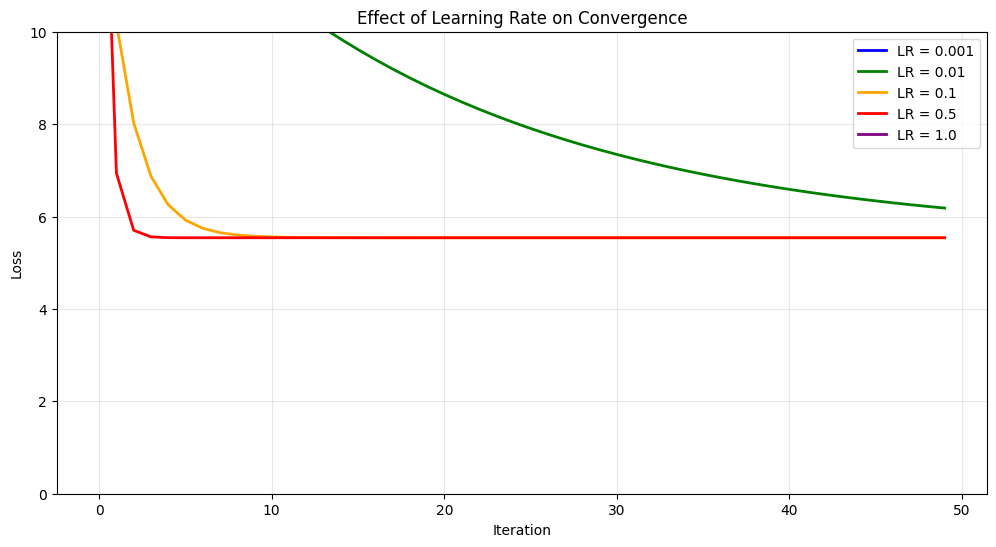


💡 ML Connection:
Learning rate is a critical hyperparameter
Too high → Model diverges
Too low → Training is very slow
Optimal → Stable and fast learning


In [10]:
# Test different learning rates
def test_learning_rates():
    learning_rates = [0.001, 0.01, 0.1, 0.5, 1.0]
    colors = ['blue', 'green', 'orange', 'red', 'purple']
    
    plt.figure(figsize=(12, 6))
    
    # Use a simple quadratic function
    def gradient_descent_lr(X, y, lr, iterations=50):
        w = np.random.randn(1)
        losses = []
        
        for _ in range(iterations):
            y_pred = w * X
            loss = np.mean((y - y_pred) ** 2)
            losses.append(loss)
            
            # Gradient
            dw = -2 * np.mean(X * (y - y_pred))
            w -= lr * dw
        
        return losses
    
    # Generate data
    np.random.seed(42)
    X_lr = np.linspace(0, 2, 100).reshape(-1, 1)
    y_lr = 3 * X_lr.flatten() + np.random.randn(100) * 0.5
    
    for lr, color in zip(learning_rates, colors):
        losses = gradient_descent_lr(X_lr, y_lr, lr)
        plt.plot(losses, color=color, label=f'LR = {lr}', linewidth=2)
    
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title('Effect of Learning Rate on Convergence')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 10)
    plt.show()

test_learning_rates()

print("\n💡 ML Connection:")
print("Learning rate is a critical hyperparameter")
print("Too high → Model diverges")
print("Too low → Training is very slow")
print("Optimal → Stable and fast learning")

###  4. Advanced Optimizers 

#### 4.1 Momentum

Momentum accelerates gradient descent by accumulating past gradients.


Iteration 0: Loss = 6.6075
Iteration 20: Loss = 0.2090
Iteration 40: Loss = 0.2120


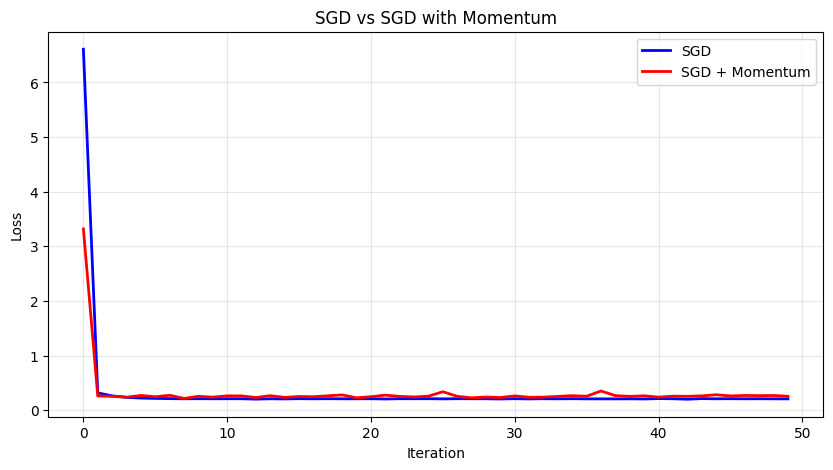


💡 ML Connection:
Momentum helps escape local minima
Accelerates convergence in areas of low gradient


In [11]:
class MomentumOptimizer:
    def __init__(self, learning_rate=0.01, momentum=0.9):
        self.lr = learning_rate
        self.momentum = momentum
        self.velocity_w = 0
        self.velocity_b = 0
    
    def update(self, weights, bias, grad_w, grad_b):
        # Update velocities
        self.velocity_w = self.momentum * self.velocity_w - self.lr * grad_w
        self.velocity_b = self.momentum * self.velocity_b - self.lr * grad_b
        
        # Update parameters
        weights += self.velocity_w
        bias += self.velocity_b
        
        return weights, bias

# Compare SGD vs Momentum
def compare_sgd_momentum():
    np.random.seed(42)
    X_mom = 2 * np.random.rand(100, 1)
    y_mom = 4 + 3 * X_mom.flatten() + np.random.randn(100) * 0.5
    
    # SGD
    sgd = StochasticGradientDescent(learning_rate=0.01, n_iterations=50)
    sgd.fit(X_mom, y_mom)
    
    # With Momentum (modified SGD)
    class SGDWithMomentum:
        def __init__(self, learning_rate=0.01, momentum=0.9):
            self.lr = learning_rate
            self.momentum = momentum
            self.weights = None
            self.bias = None
            self.loss_history = []
            self.velocity_w = 0
            self.velocity_b = 0
        
        def fit(self, X, y):
            n_samples, n_features = X.shape
            self.weights = np.zeros(n_features)
            self.bias = 0
            
            for iteration in range(50):
                # Shuffle data
                indices = np.random.permutation(n_samples)
                X_shuffled = X[indices]
                y_shuffled = y[indices]
                
                epoch_loss = 0
                
                for i in range(n_samples):
                    xi = X_shuffled[i:i+1]
                    yi = y_shuffled[i:i+1]
                    
                    # Forward pass
                    y_pred = np.dot(xi, self.weights) + self.bias
                    
                    # Gradient
                    dw = -2 * xi.T * (yi - y_pred)
                    db = -2 * (yi - y_pred)
                    
                    # Update with momentum
                    self.velocity_w = self.momentum * self.velocity_w - self.lr * dw.flatten()
                    self.velocity_b = self.momentum * self.velocity_b - self.lr * db.flatten()
                    
                    self.weights += self.velocity_w
                    self.bias += self.velocity_b
                    
                    epoch_loss += (yi - y_pred) ** 2
                
                avg_loss = epoch_loss / n_samples
                self.loss_history.append(avg_loss[0])
            
            return self
    
    sgd_momentum = SGDWithMomentum(learning_rate=0.01, momentum=0.9)
    sgd_momentum.fit(X_mom, y_mom)
    
    # Plot comparison
    plt.figure(figsize=(10, 5))
    plt.plot(sgd.loss_history, 'b-', label='SGD', linewidth=2)
    plt.plot(sgd_momentum.loss_history, 'r-', label='SGD + Momentum', linewidth=2)
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title('SGD vs SGD with Momentum')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print("\n💡 ML Connection:")
    print("Momentum helps escape local minima")
    print("Accelerates convergence in areas of low gradient")

compare_sgd_momentum()

### 4.2 Adam Optimizer

Adam combines momentum and adaptive learning rates for efficient optimization.

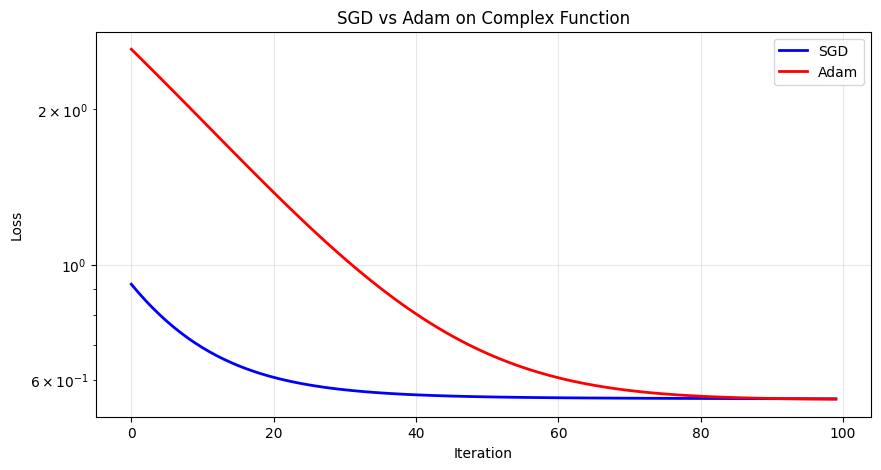


💡 ML Connection:
Adam is the most popular optimizer in deep learning
Used in GPT, BERT, Stable Diffusion, and more!


In [12]:
class AdamOptimizerDetailed:
    def __init__(self, learning_rate=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8):
        self.lr = learning_rate
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.m_w = 0
        self.v_w = 0
        self.m_b = 0
        self.v_b = 0
        self.t = 0
        
    def update(self, weights, bias, grad_w, grad_b):
        self.t += 1
        
        # Update moments for weights
        self.m_w = self.beta1 * self.m_w + (1 - self.beta1) * grad_w
        self.v_w = self.beta2 * self.v_w + (1 - self.beta2) * (grad_w ** 2)
        
        # Update moments for bias
        self.m_b = self.beta1 * self.m_b + (1 - self.beta1) * grad_b
        self.v_b = self.beta2 * self.v_b + (1 - self.beta2) * (grad_b ** 2)
        
        # Bias correction
        m_w_hat = self.m_w / (1 - self.beta1 ** self.t)
        v_w_hat = self.v_w / (1 - self.beta2 ** self.t)
        m_b_hat = self.m_b / (1 - self.beta1 ** self.t)
        v_b_hat = self.v_b / (1 - self.beta2 ** self.t)
        
        # Update parameters
        weights -= self.lr * m_w_hat / (np.sqrt(v_w_hat) + self.epsilon)
        bias -= self.lr * m_b_hat / (np.sqrt(v_b_hat) + self.epsilon)
        
        return weights, bias

# Compare optimizers on a difficult function
def compare_optimizers_difficult():
    np.random.seed(42)
    X_opt = 2 * np.random.rand(200, 1)
    y_opt = np.sin(3 * X_opt.flatten()) + np.random.randn(200) * 0.1
    
    class NeuralNetwork:
        def __init__(self):
            self.w1 = np.random.randn(1)
            self.w2 = np.random.randn(1)
            self.b = np.random.randn(1)
        
        def forward(self, X):
            return self.w1 * X + self.w2 * X**2 + self.b
        
        def loss(self, X, y):
            pred = self.forward(X)
            return np.mean((y - pred) ** 2)
        
        def gradients(self, X, y):
            pred = self.forward(X)
            grad_w1 = -2 * np.mean(X * (y - pred))
            grad_w2 = -2 * np.mean(X**2 * (y - pred))
            grad_b = -2 * np.mean(y - pred)
            return grad_w1, grad_w2, grad_b
    
    # Train with different optimizers
    def train_with_optimizer(optimizer_class, **kwargs):
        model = NeuralNetwork()
        opt = optimizer_class(**kwargs)
        losses = []
        
        for _ in range(100):
            grad_w1, grad_w2, grad_b = model.gradients(X_opt, y_opt)
            
            # Update parameters
            model.w1, model.b = opt.update(model.w1, model.b, grad_w1, grad_b)
            # For simplicity, update w2 separately
            model.w2 -= 0.001 * grad_w2
            
            losses.append(model.loss(X_opt, y_opt))
        
        return losses
    
    # Compare
    losses_sgd = train_with_optimizer(lambda **kw: type('Opt', (), {'update': lambda self, w, b, gw, gb: (w - 0.01*gw, b - 0.01*gb)})())
    
    # Simplified Adam
    class SimpleAdam:
        def __init__(self):
            self.m_w = 0
            self.v_w = 0
            self.m_b = 0
            self.v_b = 0
            self.t = 0
        
        def update(self, w, b, gw, gb):
            self.t += 1
            beta1, beta2 = 0.9, 0.999
            self.m_w = beta1 * self.m_w + 0.1 * gw
            self.v_w = beta2 * self.v_w + 0.001 * (gw ** 2)
            self.m_b = beta1 * self.m_b + 0.1 * gb
            self.v_b = beta2 * self.v_b + 0.001 * (gb ** 2)
            
            m_w_hat = self.m_w / (1 - beta1 ** self.t)
            v_w_hat = self.v_w / (1 - beta2 ** self.t)
            m_b_hat = self.m_b / (1 - beta1 ** self.t)
            v_b_hat = self.v_b / (1 - beta2 ** self.t)
            
            w -= 0.01 * m_w_hat / (np.sqrt(v_w_hat) + 1e-8)
            b -= 0.01 * m_b_hat / (np.sqrt(v_b_hat) + 1e-8)
            
            return w, b
    
    losses_adam = train_with_optimizer(SimpleAdam)
    
    plt.figure(figsize=(10, 5))
    plt.plot(losses_sgd, 'b-', label='SGD', linewidth=2)
    plt.plot(losses_adam, 'r-', label='Adam', linewidth=2)
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title('SGD vs Adam on Complex Function')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
    plt.show()
    
    print("\n💡 ML Connection:")
    print("Adam is the most popular optimizer in deep learning")
    print("Used in GPT, BERT, Stable Diffusion, and more!")

compare_optimizers_difficult()

### 5. Optimization Visualization

#### 5.1 Optimization Landscape Visualization


Visualizing the optimization landscape helps understand how different algorithms navigate towards minima.

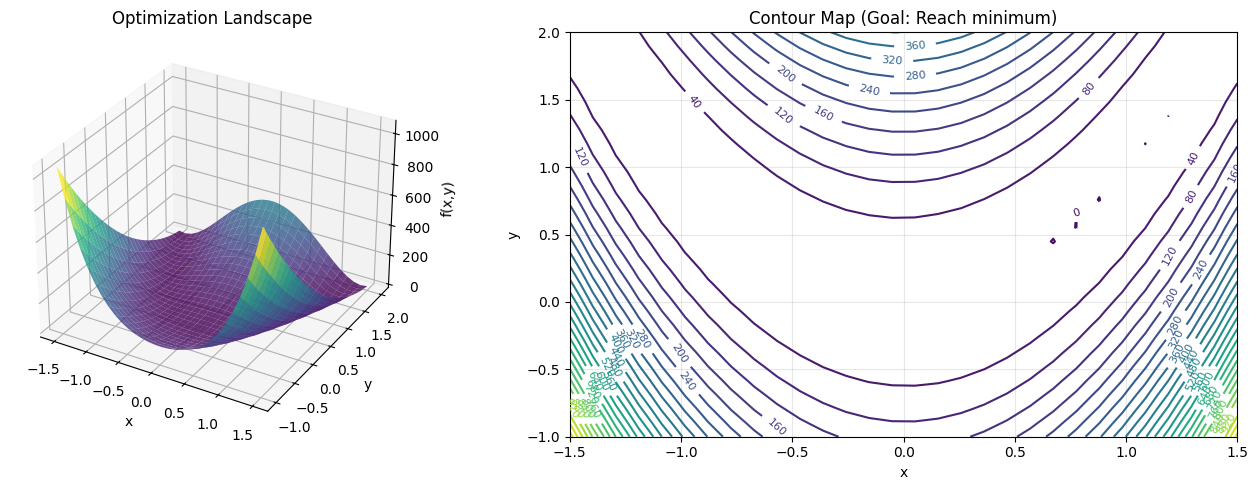


💡 ML Connection:
The goal of optimization is to find the global minimum
Complex landscapes like this exist in neural networks!


In [13]:



# Create a complex optimization landscape
def complex_function(x, y):
    """Rosenbrock-like function with multiple minima"""
    return (1 - x)**2 + 100 * (y - x**2)**2 + 0.5 * np.sin(3 * x) * np.cos(5 * y)

# Visualize the landscape
x = np.linspace(-1.5, 1.5, 30)
y = np.linspace(-1, 2, 30)
X, Y = np.meshgrid(x, y)
Z = complex_function(X, Y)

fig = plt.figure(figsize=(14, 5))

# 3D surface
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('f(x,y)')
ax1.set_title('Optimization Landscape')

# Contour with possible paths
ax2 = fig.add_subplot(122)
contour = ax2.contour(X, Y, Z, levels=30, cmap='viridis')
ax2.clabel(contour, inline=True, fontsize=8)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Contour Map (Goal: Reach minimum)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 ML Connection:")
print("The goal of optimization is to find the global minimum")
print("Complex landscapes like this exist in neural networks!")

### 6. Quick Reference Summary

#### 6.1 Optimization Cheatsheet

In [14]:

# Optimization quick reference
print("="*60)
print("⚙️ OPTIMIZATION CHEATSHEET")
print("="*60)

optimization_concepts = {
    "Loss Function": "Measures model performance",
    "Gradient Descent": "Iterative optimization algorithm",
    "Batch GD": "Uses entire dataset",
    "SGD": "Uses single sample",
    "Mini-Batch GD": "Uses small batches",
    "Learning Rate": "Controls step size",
    "Momentum": "Accumulates past gradients",
    "Adam": "Adaptive momentum optimizer",
    "Convergence": "Reaching optimal solution",
    "Global Minimum": "Best possible solution"
}

for concept, description in optimization_concepts.items():
    print(f"📌 {concept}: {description}")



⚙️ OPTIMIZATION CHEATSHEET
📌 Loss Function: Measures model performance
📌 Gradient Descent: Iterative optimization algorithm
📌 Batch GD: Uses entire dataset
📌 SGD: Uses single sample
📌 Mini-Batch GD: Uses small batches
📌 Learning Rate: Controls step size
📌 Momentum: Accumulates past gradients
📌 Adam: Adaptive momentum optimizer
📌 Convergence: Reaching optimal solution
📌 Global Minimum: Best possible solution
